## RNG

In [260]:
import numpy as np

seed = 42
rng = np.random.default_rng(seed)

## Generacja instancji

In [261]:
def generate_instance(n):
    p = rng.integers(1, 30, size=n, endpoint=True)
    w = rng.integers(1, 30, size=n, endpoint=True)
    s = np.sum(p)
    d = rng.integers(1, s, size=n, endpoint=True)

    return p, w, d

## Klasa reprezentująca osobnika

In [262]:
class Subject:
    def __init__(self, sequence):
        self.sequence = sequence
        self.fitness = None

    def evaluate_fitness(self, p, w, d):
        time = 0
        total = 0

        for i in self.sequence:
            time += p[i]
            delay = max(0, time - d[i])
            total += w[i] * delay

        self.fitness = total

## Losowanie populacji, selekcja turniejowa, krzyżowanie, mutacja

In [263]:
def init_population(size, n):
    population = []

    for _ in range(size):
        sequence = rng.permutation(n)
        subject = Subject(sequence)
        subject.evaluate_fitness(p, w, d)
        population.append(subject)

    return population

def tournament_selection(population):
    candidates = rng.choice(population, size=3, replace=False)
    best_candidate = min(candidates, key=lambda x: x.fitness)

    return best_candidate

def ox_crossover(parent1, parent2):
    n = len(parent1.sequence)
    point1, point2 = sorted(rng.choice(n, size=2, replace=False))
    child = [-1] * n
    child[point1:point2] = parent1.sequence[point1:point2]
    remaining = [x for x in parent2.sequence if x not in child]
    positions = list(range(point2, n)) + list(range(0, point1))

    for pos, val in zip(positions, remaining):
        child[pos] = val

    return Subject(np.array(child))

def mutate(subject, mutation_rate=0.05):
    if rng.random() < mutation_rate:
        i, j = rng.choice(len(subject.sequence), size=2, replace=False)
        subject.sequence[i], subject.sequence[j] = subject.sequence[j], subject.sequence[i]

    return subject

## Główna pętla algorytmu

In [264]:
_N = 100
_POPULATION_SIZE = 50
_GENERATIONS = 50
_CROSSOVER_PROBABILITY = 0.7
_MUTATION_PROBABILITY = 0.05

p, w, d = generate_instance(_N)

population = init_population(_POPULATION_SIZE, _N)
best_history = []
average_history = []
worst_history = []

for generation in range(_GENERATIONS):
    new_population = []

    best_subject = min(population, key=lambda x: x.fitness)
    elite = Subject(best_subject.sequence.copy())
    elite.fitness = best_subject.fitness
    new_population.append(elite)

    while len(new_population) < _POPULATION_SIZE:
        parent1 = tournament_selection(population)
        parent2 = tournament_selection(population)

        if rng.random() < _CROSSOVER_PROBABILITY:
            child = ox_crossover(parent1, parent2)
        else:
            best_parent = min(parent1, parent2, key=lambda x: x.fitness)
            child = Subject(best_parent.sequence.copy())

        child = mutate(child, _MUTATION_PROBABILITY)
        child.evaluate_fitness(p, w, d)
        new_population.append(child)

    population = new_population

    population_fitness = [x.fitness for x in population]
    best = min(population_fitness)
    average = sum(population_fitness) / len(population_fitness)
    worst = max(population_fitness)
    best_history.append(best)
    average_history.append(average)
    worst_history.append(worst)

    print(f"Generation {generation + 1}: best = {best}, avg = {round(average)}, worst = {worst}")

best_subject = min(population, key=lambda x: x.fitness)
print(f"Final best subject sequence: {best_subject.sequence}")
print(f"Final best subject fitness: {best_subject.fitness}")


Generation 1: best = 319011, avg = 403458, worst = 494224
Generation 2: best = 319011, avg = 412140, worst = 538585
Generation 3: best = 300371, avg = 386299, worst = 492805
Generation 4: best = 300371, avg = 403356, worst = 510449
Generation 5: best = 300371, avg = 401235, worst = 534055
Generation 6: best = 300371, avg = 382598, worst = 539207
Generation 7: best = 300371, avg = 387868, worst = 521060
Generation 8: best = 289663, avg = 369018, worst = 523749
Generation 9: best = 285176, avg = 379230, worst = 553313
Generation 10: best = 285176, avg = 378184, worst = 541793
Generation 11: best = 285176, avg = 391236, worst = 580708
Generation 12: best = 285176, avg = 363509, worst = 509315
Generation 13: best = 283006, avg = 387388, worst = 565412
Generation 14: best = 278831, avg = 377986, worst = 594112
Generation 15: best = 278831, avg = 382590, worst = 561802
Generation 16: best = 276537, avg = 356330, worst = 572152
Generation 17: best = 271896, avg = 379956, worst = 560219
Genera

## Wykresy

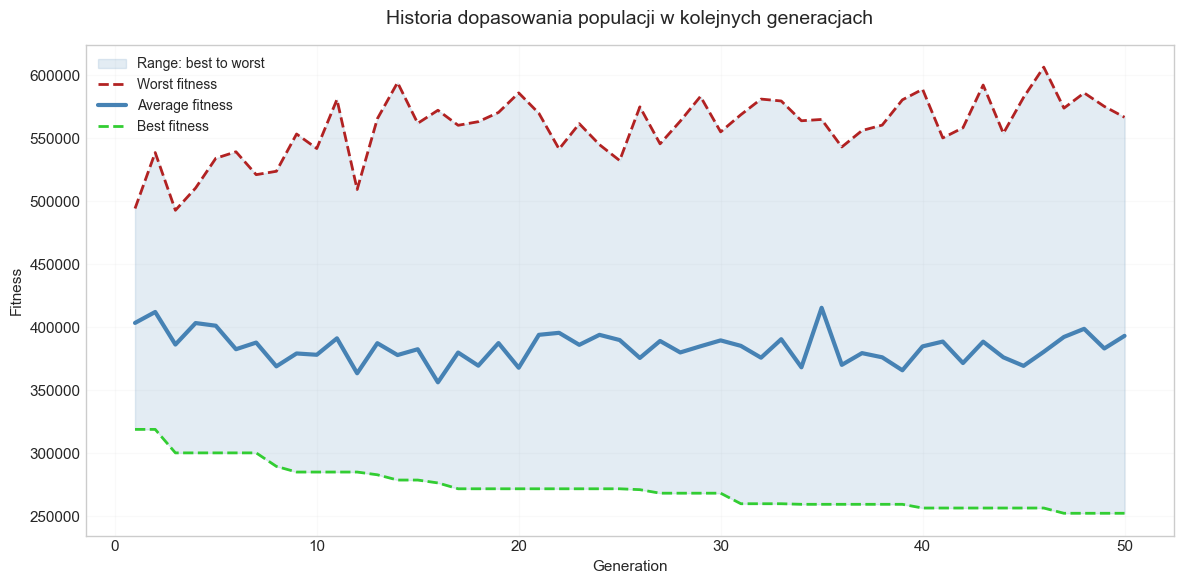

In [265]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

generations = range(1, _GENERATIONS + 1)

plt.figure(figsize=(12, 6))

plt.fill_between(
    generations,
    best_history,
    worst_history,
    color='steelblue',
    alpha=0.15,
    label='Range: best to worst'
)

plt.plot(generations, worst_history, color='firebrick', linestyle='--', linewidth=2, label='Worst fitness')
plt.plot(generations, average_history, color='steelblue', linewidth=3, label='Average fitness')
plt.plot(generations, best_history, color='limegreen', linestyle='--', linewidth=2, label='Best fitness')

plt.title('Historia dopasowania populacji w kolejnych generacjach', fontsize=14, pad=15)
plt.xlabel('Generation', fontsize=11)
plt.ylabel('Fitness', fontsize=11)
plt.grid(alpha=0.1)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()